<a href="https://colab.research.google.com/github/21anirudh/Data-Preprocessing-And-Feature-Engineering/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [40]:
df = pd.read_csv("train.csv")

In [41]:
print(df.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

In [42]:
print(df.isnull().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [43]:
train_and_test = df.copy()
train_and_test['close_to_offsite_feature'] = train_and_test['Condition1'].map(lambda x: 1 if x in ['PosN', 'PosA'] else 0)
train_and_test['close_to_busy_street'] = train_and_test['Condition1'].map(lambda x: 1 if x in ['Artery', 'Feedr'] else 0)
train_and_test.drop(columns='Condition1', inplace=True)

In [44]:
X = train_and_test.drop("SalePrice", axis=1)
y = train_and_test["SalePrice"]

In [45]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [46]:
X[num_cols] = X[num_cols].fillna(X[num_cols].mean())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

In [47]:
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [48]:
# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [49]:
median_price = y.median()
y_binary = (y > median_price).astype(int)

In [50]:
X_train, X_val, y_train, y_val, y_binary_train, y_binary_val = train_test_split(X, y, y_binary, test_size=0.2, random_state=42)

In [51]:
models = {
    # "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
}


Classification Report for Ridge Regression:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       161
           1       0.92      0.96      0.94       131

    accuracy                           0.95       292
   macro avg       0.94      0.95      0.94       292
weighted avg       0.95      0.95      0.95       292



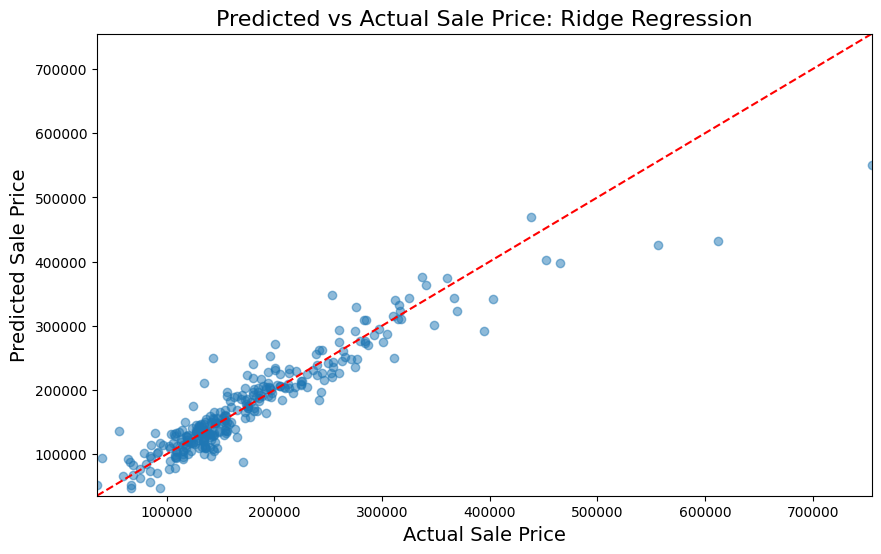

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.173e+09, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(



Classification Report for Lasso Regression:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       161
           1       0.91      0.97      0.94       131

    accuracy                           0.95       292
   macro avg       0.94      0.95      0.94       292
weighted avg       0.95      0.95      0.95       292



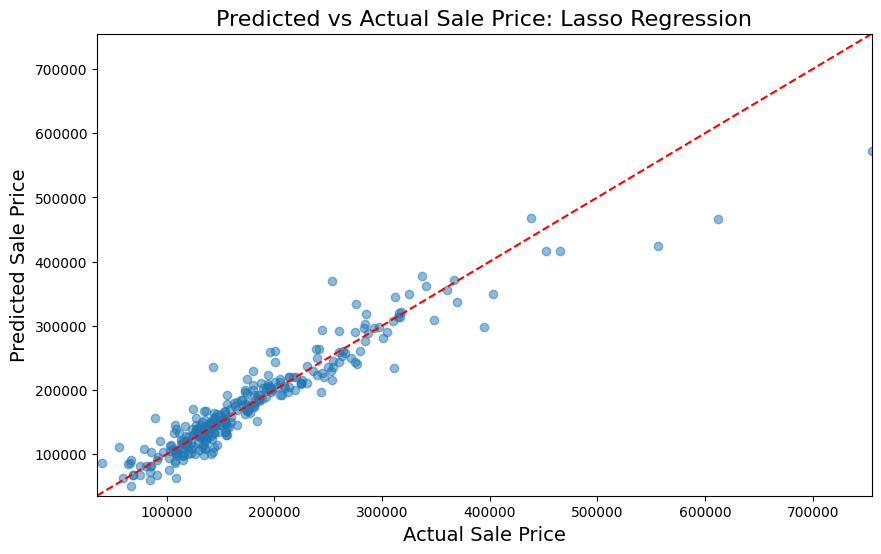


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       161
           1       0.86      0.86      0.86       131

    accuracy                           0.88       292
   macro avg       0.88      0.88      0.88       292
weighted avg       0.88      0.88      0.88       292



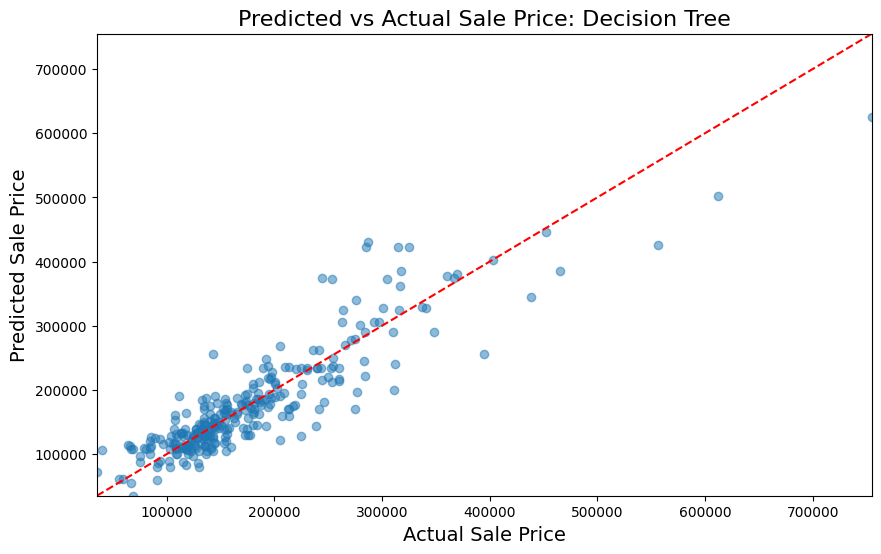


Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       161
           1       0.93      0.95      0.94       131

    accuracy                           0.95       292
   macro avg       0.94      0.95      0.94       292
weighted avg       0.95      0.95      0.95       292



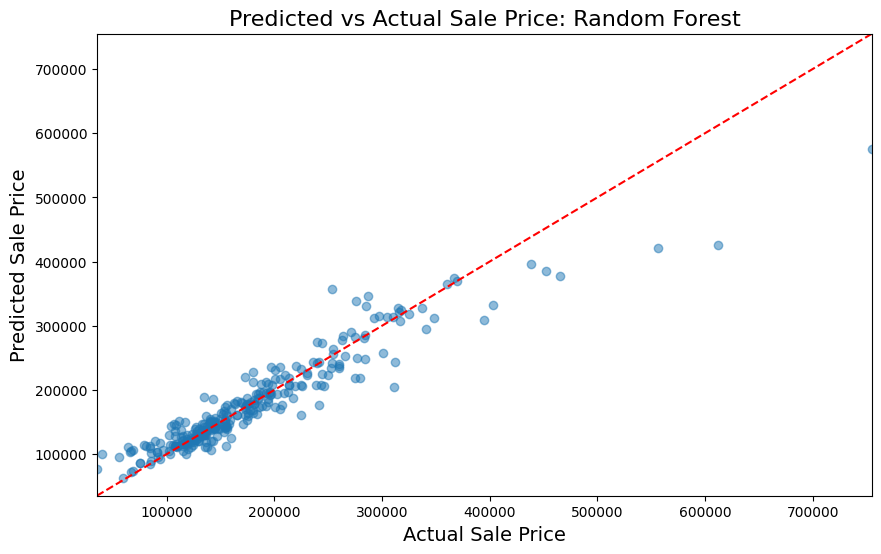

In [52]:
results = {}

for model_name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_val)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    results[model_name] = {'RMSE': rmse}

    # Convert predictions to binary for classification
    y_pred_binary = (y_pred > median_price).astype(int)

    # Calculate accuracy
    accuracy = accuracy_score(y_binary_val, y_pred_binary)
    results[model_name]['Accuracy'] = accuracy

    # Print classification report
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_binary_val, y_pred_binary))

    # Plot predicted vs actual sale price
    plt.figure(figsize=(10, 6))
    plt.scatter(y_val, y_pred, alpha=0.5)
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # Diagonal line
    plt.title(f'Predicted vs Actual Sale Price: {model_name}', fontsize=16)
    plt.xlabel('Actual Sale Price', fontsize=14)
    plt.ylabel('Predicted Sale Price', fontsize=14)
    plt.xlim(y_val.min(), y_val.max())
    plt.ylim(y_val.min(), y_val.max())
    plt.show()


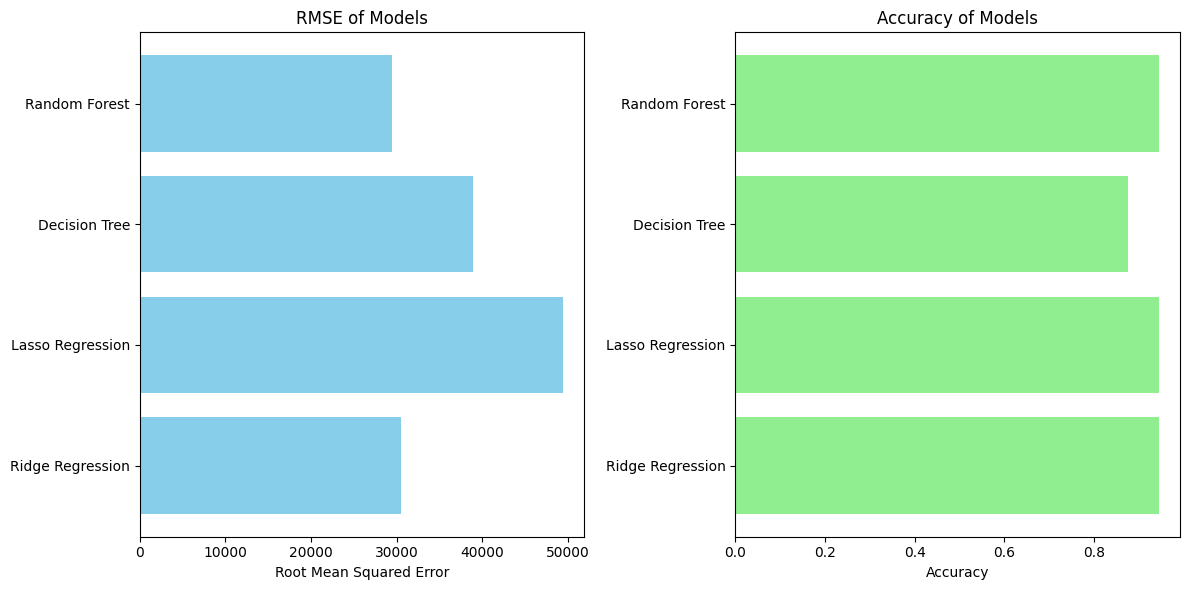

In [53]:
results_df = pd.DataFrame(results).T

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].barh(results_df.index, results_df['RMSE'], color='skyblue')
ax[0].set_xlabel('Root Mean Squared Error')
ax[0].set_title('RMSE of Models')
ax[1].barh(results_df.index, results_df['Accuracy'], color='lightgreen')
ax[1].set_xlabel('Accuracy')
ax[1].set_title('Accuracy of Models')

plt.tight_layout()
plt.show()